## Portfolio Optimization

In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize

### 1. Define Tickers and Time Range

In [4]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']  # Example tickers
# Define the start and end dates for the data retrieval
end_date = datetime.today()
start_date = end_date - timedelta(days=5*365)  # Last 5 years

In [5]:
print(start_date, end_date)

2021-08-23 18:40:36.472583 2026-08-22 18:40:36.472583


### 2. Download Adjusted Close Price

In [6]:
data = yf.download('SPY', start=start_date, end=end_date)
data.columns

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [7]:
# Define empty DataFrame to store adjusted close prices
adj_close_df = pd.DataFrame()
# Fetch adjusted close prices for each ticker
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    adj_close_df[ticker] = data['Adj Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
print(adj_close_df.head())

                  AAPL        MSFT       GOOGL        AMZN        TSLA
Date                                                                  
2021-08-23  146.022858  292.380890  138.810638  163.293503  235.433334
2021-08-24  145.935028  290.432709  140.019928  165.289001  236.163330
2021-08-25  144.706070  289.847351  140.830200  164.959000  237.066666
2021-08-26  143.906265  287.044891  140.197357  165.800003  233.720001
2021-08-27  144.940170  287.649475  142.738327  167.481506  237.306671


### 3. Calculate Log Returns

In [9]:
log_returns = np.log(adj_close_df / adj_close_df.shift(1)).dropna()
#simple_returns = adj_close_df.pct_change().dropna()

In [10]:
log_returns.head()

,AAPL,MSFT,GOOGL,AMZN,TSLA
Date,,,,,
2021-08-24,-0.000602,-0.006685,0.008674,0.012146,0.003096
2021-08-25,-0.008457,-0.002018,0.005770,-0.001999,0.003818
2021-08-26,-0.005542,-0.009716,-0.004504,0.005085,-0.014218
2021-08-27,0.007159,0.002104,0.017962,0.010091,0.015229
2021-08-30,0.029964,0.012829,0.004064,0.021250,0.026325


### 4. Calculate Covariance Matrix

In [11]:
cov_matrix = log_returns.cov() * 252  # Annualize the covariance matrix

In [12]:
print(cov_matrix)

           AAPL      MSFT     GOOGL      AMZN      TSLA
AAPL   0.078244  0.041636  0.046277  0.050435  0.077670
MSFT   0.041636  0.078465  0.049402  0.062339  0.064359
GOOGL  0.046277  0.049402  0.102771  0.072413  0.079577
AMZN   0.050435  0.062339  0.072413  0.131717  0.095164
TSLA   0.077670  0.064359  0.079577  0.095164  0.354710


### 5. Define Portfolio Performance Matrices

In [69]:
## 1. Portfolio standard deviation function
def portfolio_std(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

## 2. Portfolio return function
def portfolio_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights) * 252  # Annualized return
    #return weights @ log_returns.mean() * 252  # Annualized return


## 3. Objective function to minimize (negative Sharpe ratio)
def negative_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate=0.01):
    port_return = portfolio_return(weights, log_returns)
    port_std = portfolio_std(weights, cov_matrix)
    sharpe_ratio = (port_return - risk_free_rate) / port_std
    return -sharpe_ratio  # We minimize the negative Sharpe ratio


### 6. Portfolio Optimization

In [14]:
#pip install fredapi

In [15]:
## 1. Set the risk-free rate (U.S Treasury yield)
# from fredapi import Fred

# fred = Fred(api_key='68c50292995b0ef79a9bf99cf9dfb3ad')

# ten_year_treasury_rate = fred.get_series_latest_release('GS10') / 100

# risk_free_rate = ten_year_treasury_rate.iloc[-1]

# print("Risk-free rate:", risk_free_rate)
risk_free_rate = 0.046

In [79]:
## 2. Constraints and bounds for optimization
num_assets = len(tickers)
bounds = [(0, 0.5) for _ in range(num_assets)]  # Each weight is between 0 and 1

constraints = [{
    'type': 'eq',
    'fun': lambda weights: np.sum(weights) - 1
}]  # Weights sum to 1

In [49]:
## 3. Set initial guess for weights
initial_weights = np.array([1/num_assets] * num_assets)  # Equal weights
print("Initial weights:", initial_weights)

Initial weights: [0.2 0.2 0.2 0.2 0.2]


#### 6.1 Optimal weights based on maximum Sharpe

In [52]:
## 4. Optimize initial weights to maximize Sharpe ratio
optimized_result = minimize(
    negative_sharpe_ratio, 
    initial_weights, 
    args=(log_returns, cov_matrix, risk_free_rate), 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

In [53]:
## 5. Get optimal weights
optimal_weights = optimized_result.x
print("Optimal weights:", optimal_weights)

Optimal weights: [4.31477719e-01 0.00000000e+00 5.68522281e-01 5.99563801e-17
 0.00000000e+00]


#### 6.2 Optimal weights based on Minimum Volatility

In [54]:
optimized_result_2 = minimize(
    portfolio_std, 
    initial_weights, 
    args=(cov_matrix), 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

In [55]:
optimal_weights_2 = optimized_result_2.x
print("Optimal weights (Minimum Volatility):", optimal_weights_2)

Optimal weights (Minimum Volatility): [4.21045480e-01 3.99034637e-01 1.79919883e-01 2.71050543e-19
 1.63714528e-17]


### 7.1 Analyze the Optimal Portfolio(Maximize Sharpe)

In [56]:
## 1. Analytics for the optimized portfolio
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = portfolio_return(optimal_weights, log_returns)
optimal_portfolio_std = portfolio_std(optimal_weights, cov_matrix)
optimal_sharpe_ratio = (optimal_portfolio_return - risk_free_rate) / optimal_portfolio_std

print(f"Optimal portfolio return: {optimal_portfolio_return:.4f}")
print(f"Optimal portfolio standard deviation: {optimal_portfolio_std:.4f}")
print(f"Optimal Sharpe ratio: {optimal_sharpe_ratio:.4f}")


AAPL: 0.4315
MSFT: 0.0000
GOOGL: 0.5685
AMZN: 0.0000
TSLA: 0.0000
Optimal portfolio return: 0.1690
Optimal portfolio standard deviation: 0.2655
Optimal Sharpe ratio: 0.4635


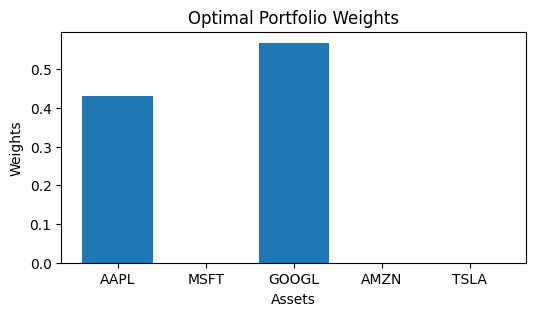

In [57]:
## Plotting the final portfolio
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.bar(tickers, optimal_weights)
plt.xlabel("Assets")
plt.ylabel("Weights")
plt.title("Optimal Portfolio Weights")
plt.show()

### 7.2 Analyze Optimal Portfolio (Minimum Volatility)

In [58]:
## 1. Analytics for the minimum volatility portfolio
for ticker, weight in zip(tickers, optimal_weights_2):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = portfolio_return(optimal_weights_2, log_returns)
optimal_portfolio_std = portfolio_std(optimal_weights_2, cov_matrix)
optimal_sharpe_ratio = (optimal_portfolio_return - risk_free_rate) / optimal_portfolio_std

print(f"Optimal portfolio return: {optimal_portfolio_return:.4f}")
print(f"Optimal portfolio standard deviation: {optimal_portfolio_std:.4f}")
print(f"Optimal Sharpe ratio: {optimal_sharpe_ratio:.4f}")

AAPL: 0.4210
MSFT: 0.3990
GOOGL: 0.1799
AMZN: 0.0000
TSLA: 0.0000
Optimal portfolio return: 0.1367
Optimal portfolio standard deviation: 0.2404
Optimal Sharpe ratio: 0.3773


# Justifying the optial weights

In [44]:
annual_returns = log_returns.mean() * 252

print("Annualized Returns:")
print(annual_returns)

print("\nAnnualized Volatility:")
print(log_returns.std() * np.sqrt(252))

print("\nCorrelation Matrix:")
print(log_returns.corr())

Annualized Returns:
AAPL     0.150860
MSFT     0.100972
GOOGL    0.182853
AMZN     0.092410
TSLA     0.086932
dtype: float64

Annualized Volatility:
AAPL     0.279721
MSFT     0.280116
GOOGL    0.320579
AMZN     0.362928
TSLA     0.595575
dtype: float64

Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN      TSLA
AAPL   1.000000  0.531383  0.516063  0.496803  0.466221
MSFT   0.531383  1.000000  0.550140  0.613201  0.385778
GOOGL  0.516063  0.550140  1.000000  0.622390  0.416788
AMZN   0.496803  0.613201  0.622390  1.000000  0.440264
TSLA   0.466221  0.385778  0.416788  0.440264  1.000000


In [45]:
annual_volatility = log_returns.std() * np.sqrt(252)

individual_sharpe = (annual_returns - risk_free_rate) / annual_volatility

print(individual_sharpe.sort_values(ascending=False))

GOOGL    0.426893
AAPL     0.374875
MSFT     0.196247
AMZN     0.127876
TSLA     0.068727
dtype: float64


# Efficient Frontier

In [61]:
import matplotlib.pyplot as plt

# Annualized expected returns
expected_returns = log_returns.mean() * 252

# Function to calculate portfolio return
def portfolio_return(weights, expected_returns):
    return weights @ expected_returns

# Function to calculate portfolio volatility
def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)


# Generate target returns
min_return = portfolio_return(optimal_weights_2, expected_returns)
max_return = expected_returns.max()

target_returns = np.linspace(min_return, max_return, 100)

frontier_returns = []
frontier_volatilities = []
frontier_weights = []


# Optimize for each target return
for target in target_returns:

    constraints_frontier = [
        {
            'type': 'eq',
            'fun': lambda weights: np.sum(weights) - 1
        },
        {
            'type': 'eq',
            'fun': lambda weights, target=target:
                portfolio_return(weights, expected_returns) - target
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_frontier
    )

    if result.success:
        frontier_returns.append(target)
        frontier_volatilities.append(
            portfolio_volatility(result.x, cov_matrix)
        )
        frontier_weights.append(result.x)

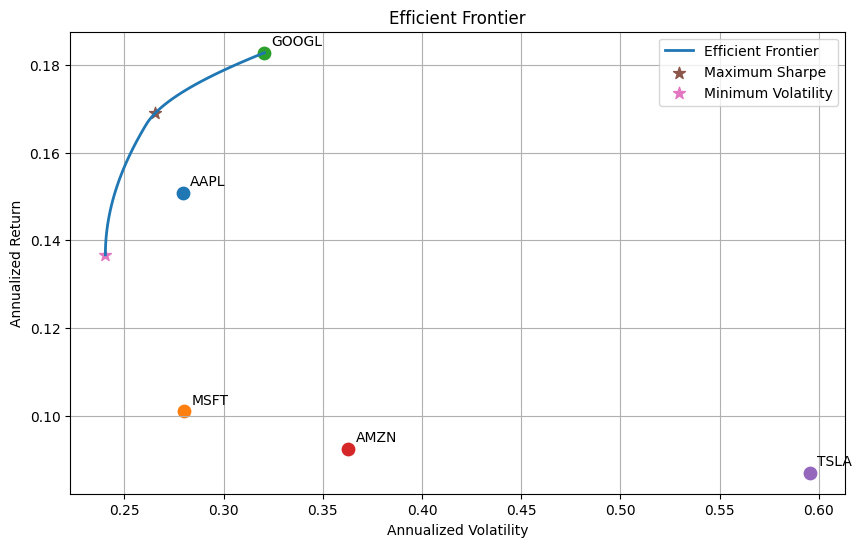

In [62]:
plt.figure(figsize=(10, 6))

# Efficient frontier
plt.plot(
    frontier_volatilities,
    frontier_returns,
    linewidth=2,
    label='Efficient Frontier'
)

# Individual assets
asset_volatilities = log_returns.std() * np.sqrt(252)

for ticker in tickers:
    plt.scatter(
        asset_volatilities[ticker],
        expected_returns[ticker],
        s=80
    )
    plt.annotate(
        ticker,
        (asset_volatilities[ticker], expected_returns[ticker]),
        xytext=(5, 5),
        textcoords='offset points'
    )

# Maximum Sharpe portfolio
max_sharpe_return = portfolio_return(
    optimal_weights,
    expected_returns
)

max_sharpe_volatility = portfolio_volatility(
    optimal_weights,
    cov_matrix
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker='*',
    s=80,
    label='Maximum Sharpe'
)

# Minimum volatility portfolio
min_vol_return = portfolio_return(
    optimal_weights_2,
    expected_returns
)

min_vol_volatility = portfolio_volatility(
    optimal_weights_2,
    cov_matrix
)

plt.scatter(
    min_vol_volatility,
    min_vol_return,
    marker='*',
    s=80,
    label='Minimum Volatility'
)

plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

# Equal weight vs Optimized portfolio

In [65]:
# Calculate individual asset metrics
expected_returns = log_returns.mean() * 252
asset_returns = expected_returns
asset_volatility = log_returns.std() * np.sqrt(252)
asset_sharpe = (asset_returns - risk_free_rate) / asset_volatility


# Maximum Sharpe portfolio metrics
max_sharpe_return = portfolio_return(
    optimal_weights,
    expected_returns
)

max_sharpe_volatility = portfolio_volatility(
    optimal_weights,
    cov_matrix
)

max_sharpe_ratio = (max_sharpe_return - risk_free_rate) / max_sharpe_volatility


# Minimum volatility portfolio metrics
min_vol_return = portfolio_return(
    optimal_weights_2,
    expected_returns
)

min_vol_volatility = portfolio_volatility(
    optimal_weights_2,
    cov_matrix
)

min_vol_sharpe = (min_vol_return - risk_free_rate) / min_vol_volatility

# Equal weight portfolio metrics
equal_weight_return = portfolio_return(
    initial_weights,
    expected_returns
)

equal_weight_volatility = portfolio_volatility(
    initial_weights,
    cov_matrix
)

equal_weight_sharpe = (equal_weight_return - risk_free_rate) / equal_weight_volatility

# Create comparison table
comparison = pd.DataFrame({
    'Annualized Return': asset_returns,
    'Annualized Volatility': asset_volatility,
    'Sharpe Ratio': asset_sharpe
})

# Add optimized portfolios
comparison.loc['Maximum Sharpe Portfolio'] = [
    max_sharpe_return,
    max_sharpe_volatility,
    max_sharpe_ratio
]

comparison.loc['Minimum Volatility Portfolio'] = [
    min_vol_return,
    min_vol_volatility,
    min_vol_sharpe
]

comparison.loc['Equal weight Portfolio'] = [
    equal_weight_return,
    equal_weight_volatility,
    equal_weight_sharpe
]

# Format percentages
comparison_display = comparison.copy()

comparison_display['Annualized Return'] = (
    comparison_display['Annualized Return'] * 100
).round(2)

comparison_display['Annualized Volatility'] = (
    comparison_display['Annualized Volatility'] * 100
).round(2)

comparison_display['Sharpe Ratio'] = (
    comparison_display['Sharpe Ratio']
).round(3)

comparison_display

,Annualized Return,Annualized Volatility,Sharpe Ratio
AAPL,15.09,27.97,0.375
MSFT,10.10,28.01,0.196
GOOGL,18.29,32.06,0.427
AMZN,9.24,36.29,0.128
TSLA,8.69,59.56,0.069
Maximum Sharpe Portfolio,16.90,26.55,0.463
Minimum Volatility Portfolio,13.67,24.04,0.377
Equal weight Portfolio,12.28,28.46,0.270


In [66]:
weights_comparison = pd.DataFrame({
    'Maximum Sharpe': optimal_weights,
    'Minimum Volatility': optimal_weights_2,
    'Equal weight' : initial_weights
}, index=tickers)

weights_comparison = weights_comparison * 100

weights_comparison.round(2)

,Maximum Sharpe,Minimum Volatility,Equal weight
AAPL,43.15,42.10,20.0
MSFT,0.00,39.90,20.0
GOOGL,56.85,17.99,20.0
AMZN,0.00,0.00,20.0
TSLA,0.00,0.00,20.0


## Out of Sample Testing

In [92]:
# ============================================
# Download SPY Benchmark
# ============================================

spy_data = yf.download(
    'SPY',
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

spy_prices = spy_data['Adj Close'].squeeze()

# Daily log returns
spy_log_returns = np.log(
    spy_prices / spy_prices.shift(1)
).dropna()

# Align SPY with our portfolio return data
spy_log_returns = spy_log_returns.reindex(
    log_returns.index
).dropna()

print("SPY observations:", len(spy_log_returns))
print("SPY period:", spy_log_returns.index[0], "to", spy_log_returns.index[-1])

SPY observations: 1254
SPY period: 2021-08-24 00:00:00 to 2026-08-21 00:00:00


In [ ]:
# ============================================
# Rolling Window Backtest
# ============================================

LOOKBACK = 3*252       # 3 year of trading days
REBALANCE = 63       # approximately quarterly

backtest_returns = log_returns.copy()

# Store portfolio daily returns
max_sharpe_returns = []
min_vol_returns = []
equal_weight_returns = []
spy_returns = []

# Store portfolio weights at each rebalance
weight_history_sharpe = []
weight_history_minvol = []

rebalance_dates = []

In [74]:
len(backtest_returns)

1254

### 2. Rolling Window Optimization

In [116]:
for start in range(LOOKBACK, len(backtest_returns), REBALANCE):

    # ----------------------------------------
    # Training window
    # ----------------------------------------
    
    train_data = backtest_returns.iloc[start - LOOKBACK : start]

    # Estimate expected returns and covariance
    train_expected_returns = train_data.mean() * 252
    train_cov_matrix = train_data.cov() * 252

    # ----------------------------------------
    # Maximum Sharpe optimization
    # ----------------------------------------

    sharpe_result = minimize(
        negative_sharpe_ratio,
        initial_weights,
        args=(
            train_data,
            train_cov_matrix,
            risk_free_rate
        ),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    sharpe_weights = sharpe_result.x

    # ----------------------------------------
    # Minimum Volatility optimization
    # ----------------------------------------

    minvol_result = minimize(
        portfolio_std,
        initial_weights,
        args=(train_cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    minvol_weights = minvol_result.x

    equal_weights = initial_weights
    # ----------------------------------------
    # Store weights
    # ----------------------------------------

    weight_history_sharpe.append(sharpe_weights)
    weight_history_minvol.append(minvol_weights)

    rebalance_dates.append(backtest_returns.index[start])

    # ----------------------------------------
    # Determine holding period
    # ----------------------------------------

    end = min(start + REBALANCE, len(backtest_returns))

    holding_period = backtest_returns.iloc[start:end]

    # ----------------------------------------
    # Calculate realized portfolio returns
    # ----------------------------------------

    sharpe_portfolio = holding_period @ sharpe_weights

    minvol_portfolio = holding_period @ minvol_weights

    equal_portfolio = holding_period @ equal_weights

    # Store realized returns
    max_sharpe_returns.append(sharpe_portfolio)
    min_vol_returns.append(minvol_portfolio)
    equal_weight_returns.append(equal_portfolio)

    # SPY benchmark
    spy_holding_period = spy_log_returns.reindex(
        holding_period.index
    ).dropna()

    spy_returns.append(spy_holding_period)


### 3. Combining the realized returns

In [117]:
max_sharpe_returns = pd.concat(max_sharpe_returns)
min_vol_returns = pd.concat(min_vol_returns)
equal_weight_returns = pd.concat(equal_weight_returns)
spy_returns = pd.concat(spy_returns)

In [118]:
max_sharpe_returns

Date
2024-08-27    0.002290
2024-08-28   -0.007318
2024-08-29    0.010292
2024-08-30    0.003120
2024-09-03   -0.023107
                ...   
2026-08-17   -0.004263
2026-08-18    0.002367
2026-08-19    0.012230
2026-08-20   -0.015709
2026-08-21    0.003050
Length: 498, dtype: float64

In [119]:
rebalance_dates

[Timestamp('2024-08-27 00:00:00'),
 Timestamp('2024-11-25 00:00:00'),
 Timestamp('2025-02-28 00:00:00'),
 Timestamp('2025-05-30 00:00:00'),
 Timestamp('2025-08-29 00:00:00'),
 Timestamp('2025-11-28 00:00:00'),
 Timestamp('2026-03-03 00:00:00'),
 Timestamp('2026-06-02 00:00:00')]

In [120]:
cumulative_sharpe = (1 + max_sharpe_returns).cumprod()

cumulative_minvol = (1 + min_vol_returns).cumprod()

cumulative_equal = (1 + equal_weight_returns).cumprod()

cumulative_spy = (1 + spy_returns).cumprod()

### 4. Ploting Performance Curves

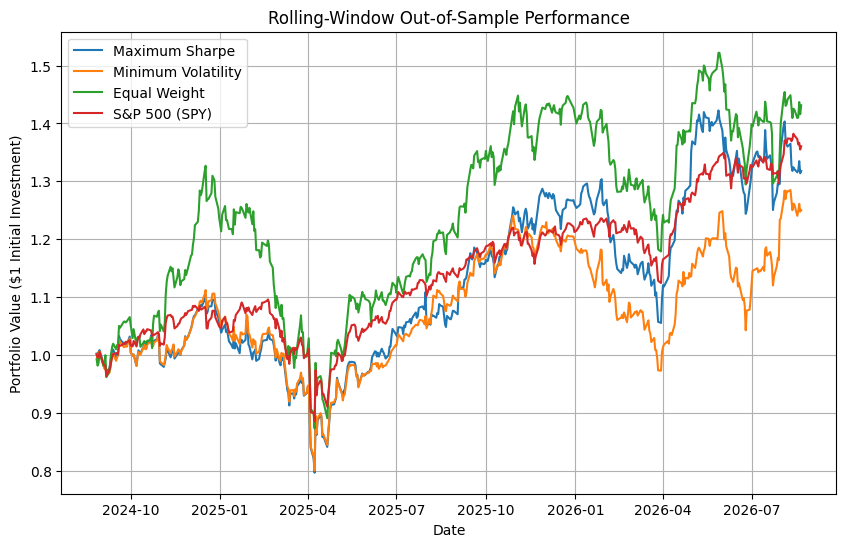

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    cumulative_sharpe,
    label='Maximum Sharpe'
)

plt.plot(
    cumulative_minvol,
    label='Minimum Volatility'
)

plt.plot(
    cumulative_equal,
    label='Equal Weight'
)

plt.plot(
    cumulative_spy,
    label='S&P 500 (SPY)'
)
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($1 Initial Investment)')
plt.title('Rolling-Window Out-of-Sample Performance')
plt.legend()
plt.grid(True)

plt.show()

### 5. How weights change

In [122]:
sharpe_weights_df = pd.DataFrame(
    weight_history_sharpe,
    index=rebalance_dates,
    columns=tickers
)

minvol_weights_df = pd.DataFrame(
    weight_history_minvol,
    index=rebalance_dates,
    columns=tickers
)

In [88]:
print("Maximum Sharpe Portfolio Weights:")
print(sharpe_weights_df.round(3))

print("\nMinimum Volatility Portfolio Weights:")
print(minvol_weights_df.round(3))

Maximum Sharpe Portfolio Weights:
             AAPL   MSFT  GOOGL   AMZN   TSLA
2022-08-24  0.500  0.000  0.000  0.000  0.500
2022-11-22  0.500  0.500  0.000  0.000  0.000
2023-02-24  0.500  0.500  0.000  0.000  0.000
2023-05-25  0.500  0.500  0.000  0.000  0.000
2023-08-25  0.000  0.500  0.500  0.000  0.000
2023-11-24  0.141  0.500  0.095  0.264  0.000
2024-02-27  0.000  0.500  0.090  0.410  0.000
2024-05-28  0.000  0.438  0.201  0.361  0.000
2024-08-27  0.363  0.500  0.013  0.124  0.000
2024-11-25  0.386  0.000  0.000  0.500  0.114
2025-02-28  0.500  0.000  0.297  0.157  0.046
2025-05-30  0.000  0.316  0.000  0.184  0.500
2025-08-29  0.000  0.449  0.228  0.192  0.131
2025-11-28  0.083  0.417  0.500  0.000  0.000
2026-03-03  0.206  0.205  0.500  0.000  0.089
2026-06-02  0.500  0.000  0.500  0.000  0.000

Minimum Volatility Portfolio Weights:
             AAPL   MSFT  GOOGL   AMZN  TSLA
2022-08-24  0.447  0.449  0.103  0.000   0.0
2022-11-22  0.436  0.467  0.097  0.000   0.0
2023-02-24

# Performance Comparison

In [89]:
def calculate_metrics(returns, risk_free_rate):
    
    # Total cumulative return
    cumulative_return = (1 + returns).prod() - 1
    
    # Number of years in test period
    years = len(returns) / 252
    
    # CAGR
    annualized_return = (1 + cumulative_return) ** (1 / years) - 1
    
    # Annualized volatility
    annualized_volatility = returns.std() * np.sqrt(252)
    
    # Sharpe ratio
    sharpe = (
        annualized_return - risk_free_rate
    ) / annualized_volatility
    
    # Cumulative wealth
    wealth = (1 + returns).cumprod()
    
    # Running maximum
    running_max = wealth.cummax()
    
    # Drawdown
    drawdown = wealth / running_max - 1
    
    # Maximum drawdown
    max_drawdown = drawdown.min()
    
    return {
        'Total Return': cumulative_return,
        'CAGR': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe,
        'Maximum Drawdown': max_drawdown
    }

In [123]:
rolling_comparison = pd.DataFrame({
    'Equal Weight': calculate_metrics(
        equal_weight_returns,
        risk_free_rate
    ),

    'Maximum Sharpe': calculate_metrics(
        max_sharpe_returns,
        risk_free_rate
    ),

    'Minimum Volatility': calculate_metrics(
        min_vol_returns,
        risk_free_rate
    ),

     'S&P 500 (SPY)': calculate_metrics(
        spy_returns,
        risk_free_rate
    )
}).T

In [124]:
percentage_columns = [
    'Total Return',
    'CAGR',
    'Annualized Volatility',
    'Maximum Drawdown'
]

display_table = rolling_comparison.copy()

display_table[percentage_columns] *= 100

display(display_table.round(2))

,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Equal Weight,43.14,19.90,26.79,0.57,-34.21
Maximum Sharpe,31.78,14.99,23.86,0.44,-27.87
Minimum Volatility,25.03,11.97,22.47,0.33,-28.03
S&P 500 (SPY),36.05,16.85,16.58,0.74,-19.21


# Investigating low CAGR for Max Sharpe

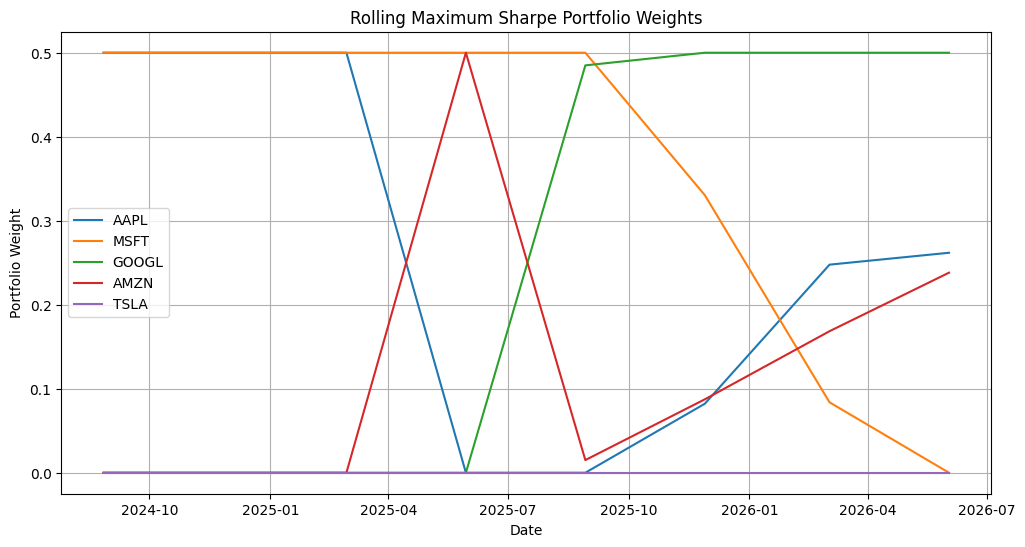

In [125]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(
        sharpe_weights_df.index,
        sharpe_weights_df[ticker],
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.title("Rolling Maximum Sharpe Portfolio Weights")
plt.legend()
plt.grid(True)
plt.show()

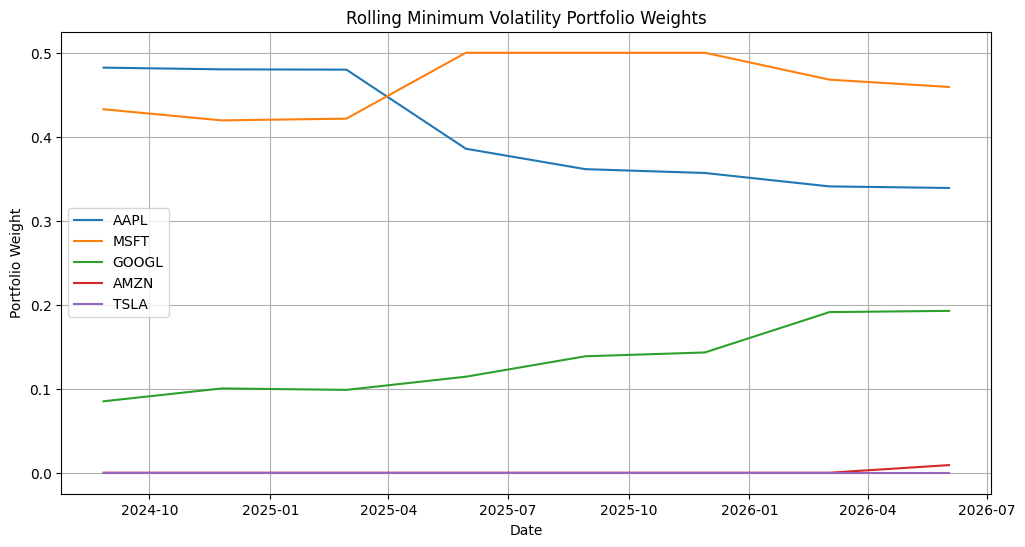

In [126]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(
        minvol_weights_df.index,
        minvol_weights_df[ticker],
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.title("Rolling Minimum Volatility Portfolio Weights")
plt.legend()
plt.grid(True)
plt.show()